# Daylan et al. (2021a) transits of HD 108236 (TOI-1233)

This notebook reproduces the four-planet TESS transit analysis of Daylan et al. (2021a), *AJ*, 161, 85 (DOI 10.3847/1538-3881/abd73e). It uses the TESS Sectors 10 and 11 SPOC light curves retrieved and detrended by Miletos. PCAT samples a model of four transiting planets (batman; Kreidberg 2015) with free epochs, periods, radius ratios, scaled semi-major axes, inclinations, and shared quadratic limb darkening, fitting a window of ±0.35 day around each transit with a marginalized linear baseline and white-noise jitter. Planet radii use the stellar radius of the paper, 0.888 ± 0.017 R☉. The paper's ground-based photometry and Doppler spectroscopy are not part of this reproduction, which uses TESS data only.

In [1]:
from IPython.display import Image, display

from miletos import daylan2021a
from miletos.paths import get_repository_path

visual_path = get_repository_path() / 'examples' / 'TOI-1233' / 'visuals'

## Sample the four-planet posterior with PCAT

Four chains of 400,000 sweeps each take about an hour. Set `boolreus=True` to reuse a saved posterior.

In [2]:
samples, radi, state = daylan2021a.fit_daylan2021a_transits(numbchan=4, numbsamp=150000, numbburn=250000,
                                                             boolreus=True)
daylan2021a.plot_daylan2021a_transits(samples, radi, state)

## Compare with the published radii and periods

In [3]:
for line in daylan2021a.retr_summary_daylan2021a(samples, radi):
    print(line)

b: radius 1.542 (+0.14 / -0.10) R_earth, published 1.586 (+0.098 / -0.098); period 3.79543 (+0.00059 / -0.00059) day, published 3.79523
c: radius 2.011 (+0.14 / -0.10) R_earth, published 2.068 (+0.1 / -0.091); period 6.20388 (+0.00049 / -0.00049) day, published 6.2037
d: radius 2.806 (+0.32 / -0.18) R_earth, published 2.72 (+0.11 / -0.11); period 14.17618 (+0.00307 / -0.00378) day, published 14.17555
e: radius 3.110 (+0.19 / -0.17) R_earth, published 3.12 (+0.13 / -0.12); period 19.59788 (+0.00246 / -0.00282) day, published 19.5917


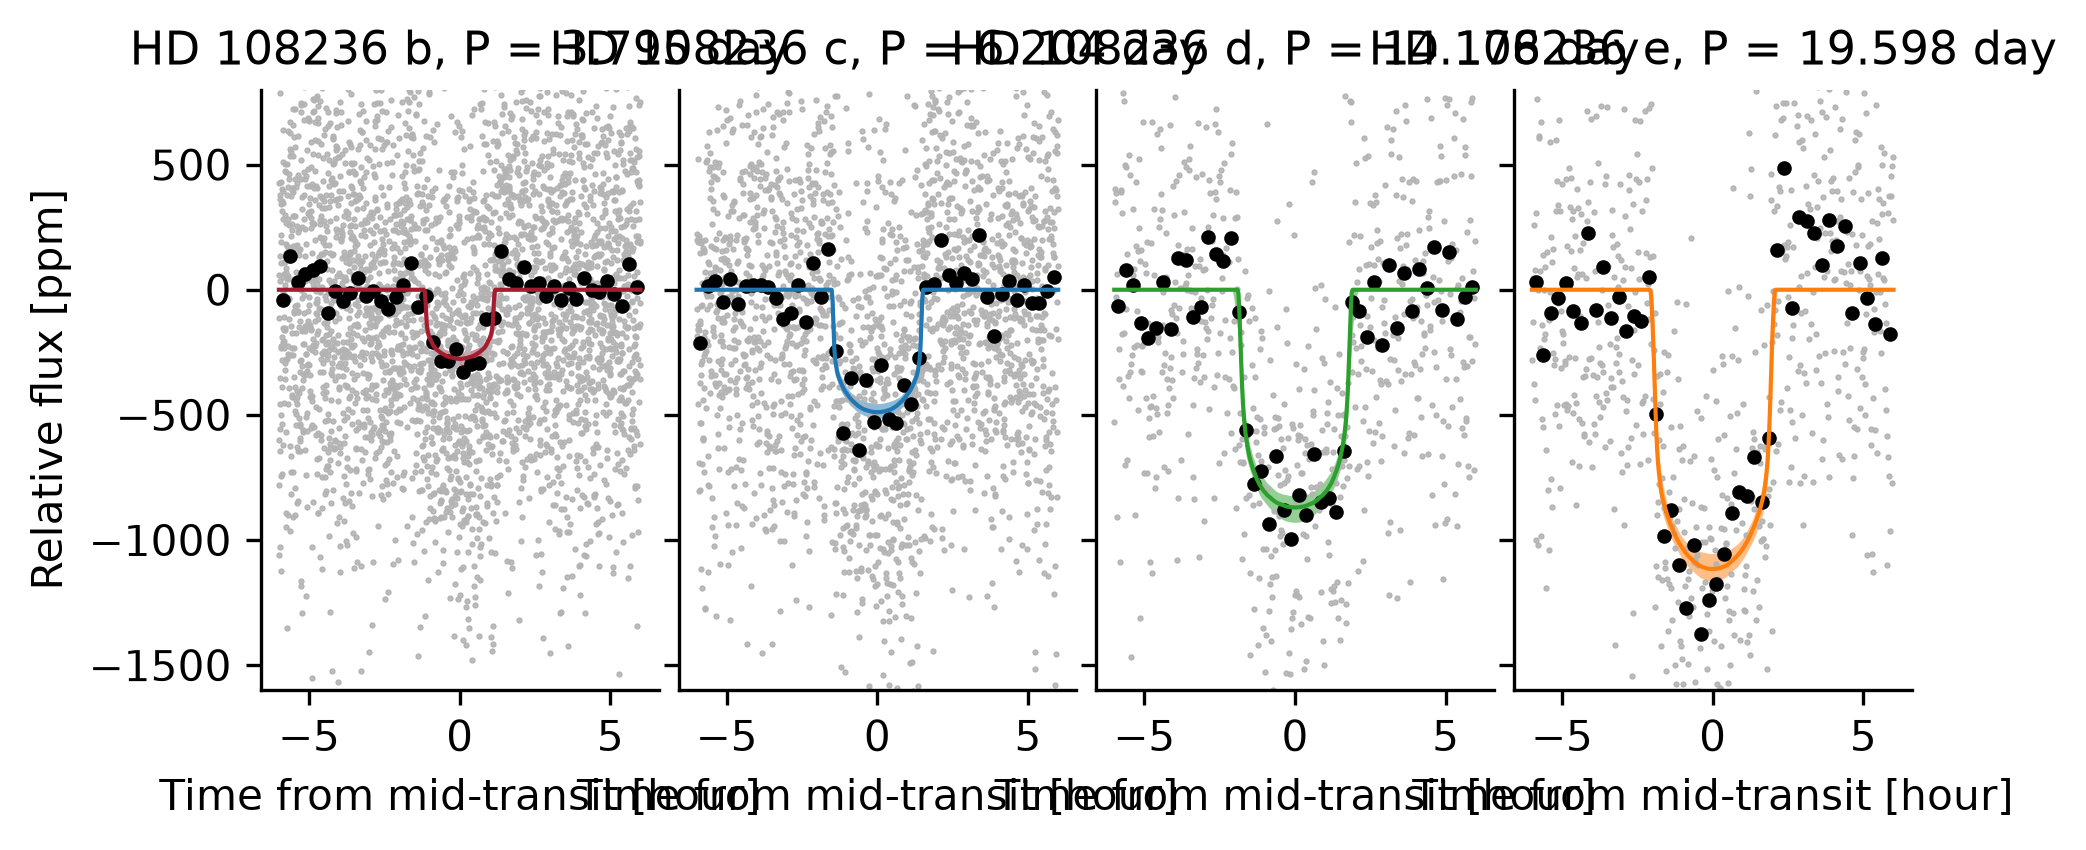

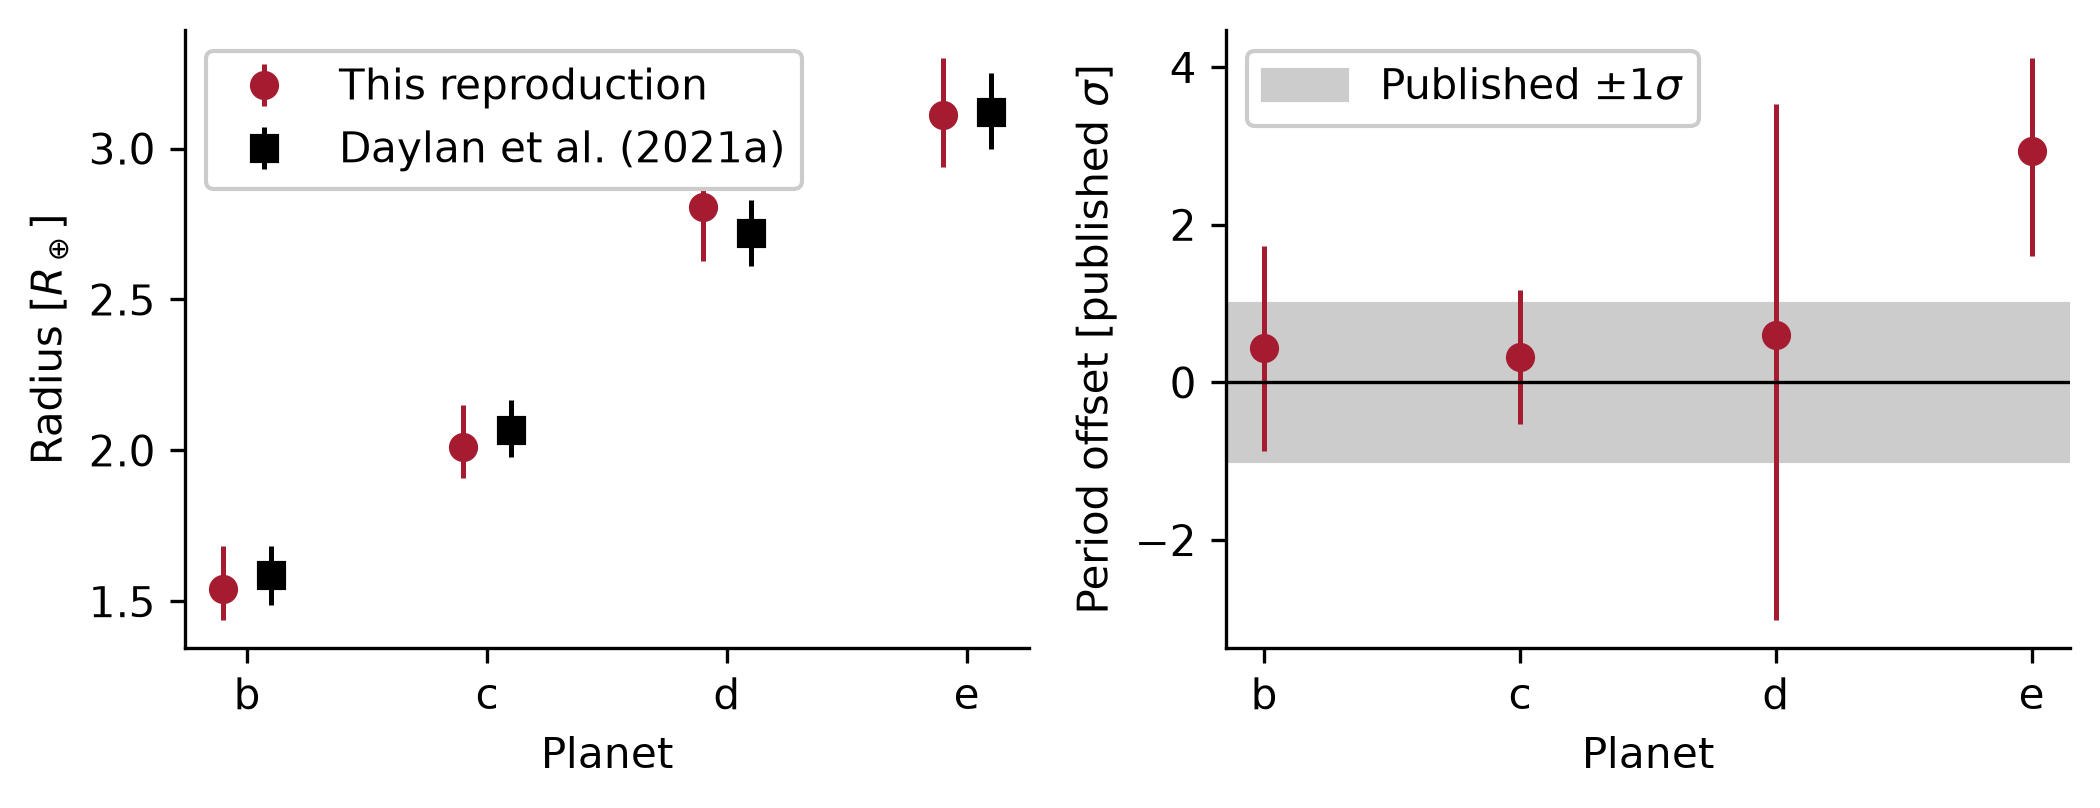

In [4]:
for path in sorted(visual_path.glob('daylan2021a_*.png')):
    display(Image(filename=str(path)))